# Hard Hat Detection — YOLOv8 for construction-site safety

**Can a detector tell, from one frame, which heads on a site are protected and which are not?**

That is the whole task, and it is a detection task rather than a classification one: a single
photo can hold twenty workers, and the answer is *per head*, not per image.

This notebook fine-tunes **YOLOv8s** on the
[Hard Hat Detection dataset](https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection)
(5,000 annotated images, Pascal VOC boxes) and reports the numbers that matter for a safety
alarm — above all **recall on the `head` class**, because a missed bare head is a missed
violation, while a false alarm only costs someone a second glance.

| | |
|---|---|
| Data | 5,000 images · 25,502 boxes · Pascal VOC XML |
| Classes trained | `helmet` (protected head) · `head` (unprotected head) |
| Model | YOLOv8s, COCO-pretrained, fine-tuned 30 epochs @ 416 px |
| Hardware | Apple M3 (16 GB unified memory), MPS backend |
| Splits | 3,500 train / 1,000 val / 500 test, stratified on violation presence |

The pipeline is scripted so it reproduces end to end:

```bash
python get_data.py          # 5,000 images + VOC annotations into data/
python prepare_dataset.py   # VOC -> YOLO, stratified split, data.yaml
python train.py             # yolov8s, 30 epochs, 416 px
python evaluate.py --weights runs/detect/yolov8s_416px_30e/weights/best.pt
```

This notebook is the narrative over those scripts: what the data looks like, why the
conversion and the split were done this way, and how well the trained model actually works.

In [1]:
import json, os, glob, random, xml.etree.ElementTree as ET
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10})
SEED = 42
random.seed(SEED); np.random.seed(SEED)

COLORS = {"helmet": "#16a34a", "head": "#ef4444", "person": "#3b82f6"}
IMAGES, ANNOTATIONS = "data/images", "data/annotations"
RUN = "runs/detect/yolov8s_416px_30e"

print("images:", len(os.listdir(IMAGES)), " annotations:", len(os.listdir(ANNOTATIONS)))

images: 5000  annotations: 5000


## 1. What is in the data

Every image ships with a Pascal VOC XML file: image size, then one `<object>` per box with a
class name and pixel corners. Nothing is inferred here — the loop below just reads all 5,000
files into a dataframe of boxes so the dataset can be looked at as data rather than as files.

In [2]:
rows = []
for xml_path in sorted(glob.glob(f"{ANNOTATIONS}/*.xml")):
    root = ET.parse(xml_path).getroot()
    size = root.find("size")
    w, h = int(size.find("width").text), int(size.find("height").text)
    stem = os.path.basename(xml_path)[:-4]
    for obj in root.findall("object"):
        b = obj.find("bndbox")
        xmin, ymin, xmax, ymax = (float(b.find(k).text) for k in ("xmin", "ymin", "xmax", "ymax"))
        rows.append({"image": stem, "cls": obj.find("name").text,
                     "img_w": w, "img_h": h,
                     "w": xmax - xmin, "h": ymax - ymin,
                     "area_frac": ((xmax - xmin) * (ymax - ymin)) / (w * h)})

boxes = pd.DataFrame(rows)
print(f"{len(boxes):,} boxes over {boxes.image.nunique():,} images")
boxes.cls.value_counts().to_frame("boxes").assign(share=lambda d: (d.boxes / len(boxes)).map("{:.1%}".format))

25,502 boxes over 5,000 images


,boxes,share
cls,,
helmet,18966,74.4%
head,5785,22.7%
person,751,2.9%


Three classes, wildly unbalanced: `helmet` outnumbers `head` 3.3:1 and `person` 25:1.

`person` is also *semantically different* — it marks a whole body, usually when the head is
too small or occluded to label, so it does not answer "is this worker protected?". It is
dropped in `prepare_dataset.py`; the model is trained on the safety-relevant pair
`helmet` / `head`. (Flip `KEEP_PERSON = True` there to train the 3-class variant.)

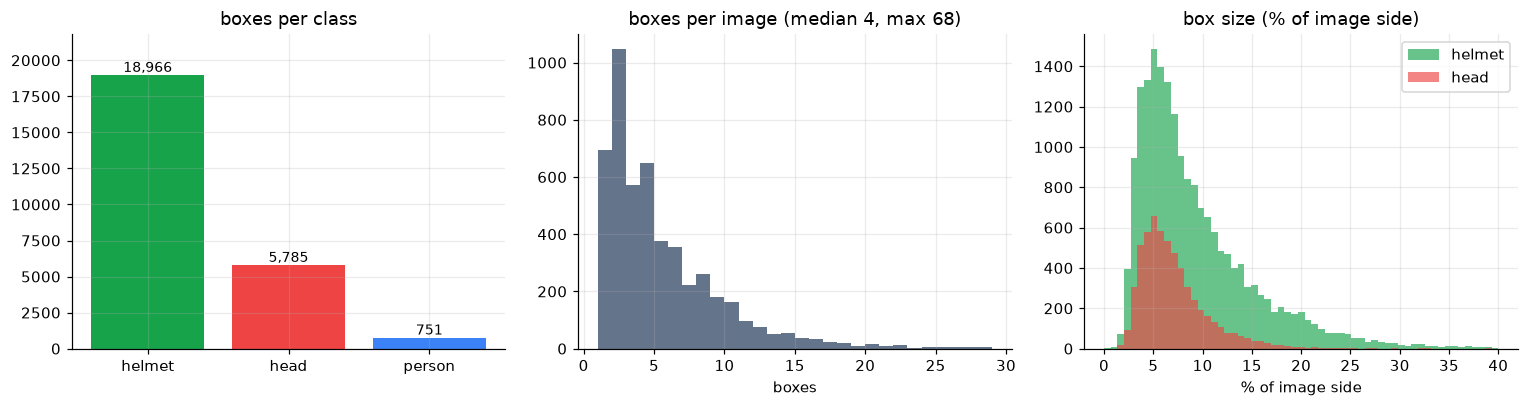

25% of boxes are under 5% of the image side — this is a small-object problem.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

counts = boxes.cls.value_counts()
axes[0].bar(counts.index, counts.values, color=[COLORS[c] for c in counts.index])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("boxes per class"); axes[0].set_ylim(0, counts.max() * 1.15)

per_image = boxes.groupby("image").size()
axes[1].hist(per_image, bins=range(1, 30), color="#64748b")
axes[1].set_title(f"boxes per image (median {per_image.median():.0f}, max {per_image.max()})")
axes[1].set_xlabel("boxes")

for cls in ["helmet", "head"]:
    side = np.sqrt(boxes.loc[boxes.cls == cls, "area_frac"]) * 100
    axes[2].hist(side, bins=np.linspace(0, 40, 60), alpha=0.65, label=cls, color=COLORS[cls])
axes[2].set_title("box size (% of image side)"); axes[2].set_xlabel("% of image side"); axes[2].legend()
plt.tight_layout(); plt.show()

tiny = (np.sqrt(boxes.area_frac) < 0.05).mean()
print(f"{tiny:.0%} of boxes are under 5% of the image side — this is a small-object problem.")

That third panel is the difficulty of the dataset in one picture: most heads are a handful of
pixels across in a 416x416 frame — this is a small-object detection problem, and it is where
the model will lose most of its recall.

It also settles the input resolution. Ultralytics defaults to 640 px, which upsamples these
images and gives YOLO's stride-8 feature map more cells per head. That was measured first and
dropped: at 640 px with batch 16 the run pushed unified memory past 7 GB on this 16 GB M3, the
machine began swapping, and an iteration went from **1.0 s to ~50 s** — a 30-epoch run would
have taken more than a day. Training therefore runs at the images' **native 416 px**, where no
information is invented and an epoch takes about 4 minutes.

In [4]:
per_image_cls = boxes.pivot_table(index="image", columns="cls", aggfunc="size", fill_value=0)
violation_images = (per_image_cls["head"] > 0).sum()
print(f"images with at least one unprotected head: {violation_images:,} "
      f"({violation_images / len(per_image_cls):.1%})")
print(f"images that are all-compliant:             {len(per_image_cls) - violation_images:,}")

images with at least one unprotected head: 920 (18.4%)
images that are all-compliant:             4,080


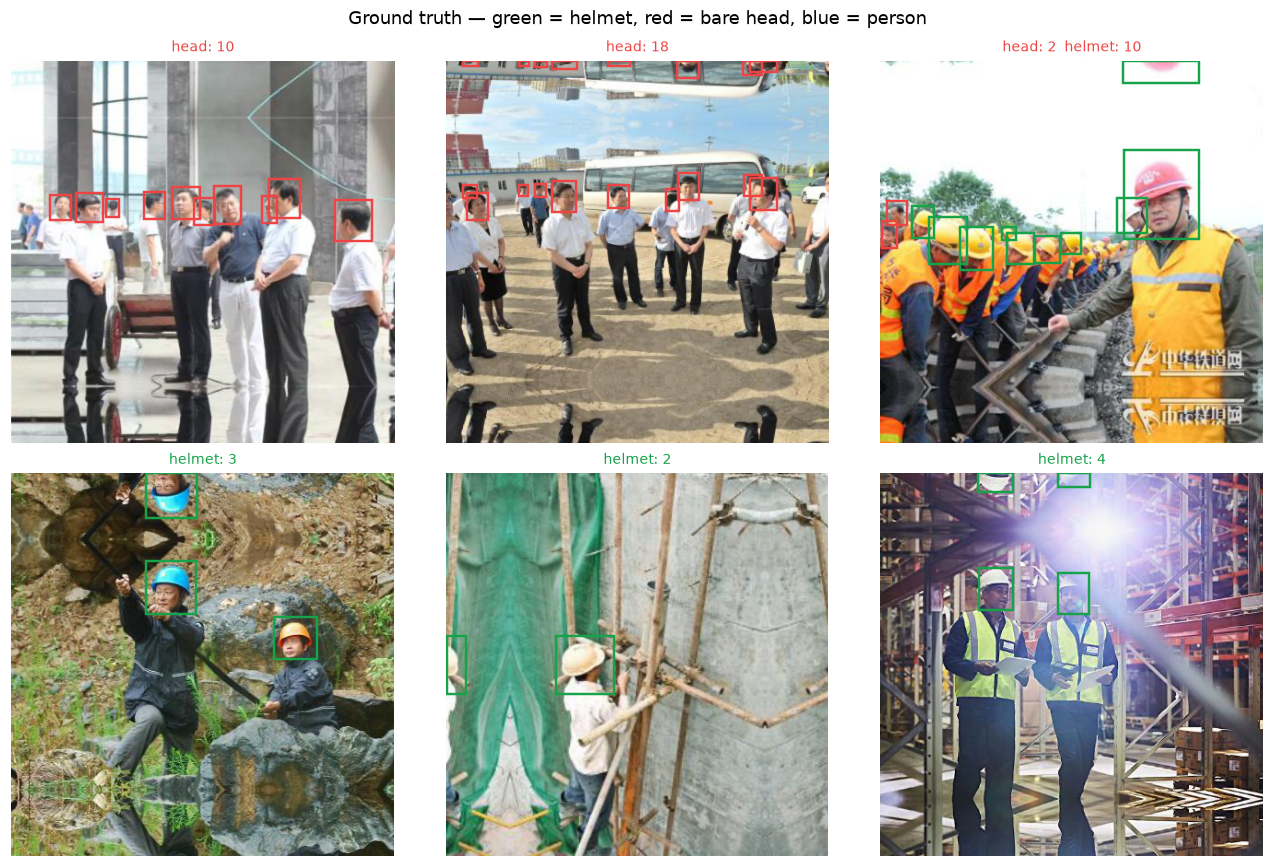

In [5]:
# A look at the raw images with their ground-truth boxes.
import matplotlib.patches as patches

with_head = sorted(per_image_cls.index[per_image_cls["head"] > 0])
picks = random.Random(SEED).sample(with_head, 3) + random.Random(SEED).sample(
    sorted(per_image_cls.index[per_image_cls["head"] == 0]), 3)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, stem in zip(axes.ravel(), picks):
    ax.imshow(Image.open(f"{IMAGES}/{stem}.png"))
    root = ET.parse(f"{ANNOTATIONS}/{stem}.xml").getroot()
    tally = Counter()
    for obj in root.findall("object"):
        name = obj.find("name").text
        tally[name] += 1
        b = obj.find("bndbox")
        xmin, ymin, xmax, ymax = (float(b.find(k).text) for k in ("xmin", "ymin", "xmax", "ymax"))
        ax.add_patch(patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                       fill=False, lw=1.6, edgecolor=COLORS[name]))
    ax.set_title("  ".join(f"{k}: {v}" for k, v in sorted(tally.items())), fontsize=9,
                 color="#ef4444" if tally["head"] else "#16a34a")
    ax.axis("off")
fig.suptitle("Ground truth — green = helmet, red = bare head, blue = person", fontsize=12)
plt.tight_layout(); plt.show()

## 2. Pascal VOC → YOLO

YOLO wants one `.txt` per image, one line per box:

```
<class_id> <x_center> <y_center> <width> <height>
```

with every coordinate **normalised to [0, 1]**. VOC gives absolute pixel corners, so the
conversion is: pick up the class id, divide by the image size, and move from corners to
centre + extent. `prepare_dataset.py` does this for all 5,000 files; here is the same
transformation on a single annotation so the arithmetic is visible.

In [6]:
sample = picks[0]
print(open(f"{ANNOTATIONS}/{sample}.xml").read()[:700], "...\n")

<annotation>
    <folder>images</folder>
    <filename>hard_hat_workers4143.png</filename>
    <size>
        <width>416</width>
        <height>415</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>head</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>220</xmin>
            <ymin>136</ymin>
            <xmax>249</xmax>
            <ymax>177</ymax>
        </bndbox>
    </object>
    <object>
        <name>head</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
       ...



In [7]:
from prepare_dataset import voc_to_yolo, CLASSES

lines, labels = voc_to_yolo(f"{ANNOTATIONS}/{sample}.xml")
print(f"{sample}: {len(labels)} VOC objects {dict(Counter(labels))} -> {len(lines)} YOLO lines\n")
print("\n".join(lines[:6]))

hard_hat_workers4143: 10 VOC objects {'head': 10} -> 10 YOLO lines

1 0.563702 0.377108 0.069712 0.098795
1 0.203125 0.383133 0.069712 0.077108
1 0.711538 0.359036 0.081731 0.101205
1 0.891827 0.416867 0.096154 0.106024
1 0.454327 0.371084 0.072115 0.081928
1 0.127404 0.381928 0.052885 0.065060


In [8]:
# Round-trip check: convert the YOLO line back to pixel corners and compare with the XML.
root = ET.parse(f"{ANNOTATIONS}/{sample}.xml").getroot()
W = int(root.find("size/width").text); H = int(root.find("size/height").text)
kept = [o for o in root.findall("object") if o.find("name").text in CLASSES]

worst = 0.0
for obj, line in zip(kept, lines):
    b = obj.find("bndbox")
    voc = [float(b.find(k).text) for k in ("xmin", "ymin", "xmax", "ymax")]
    _, cx, cy, w, h = (float(v) for v in line.split())
    back = [(cx - w / 2) * W, (cy - h / 2) * H, (cx + w / 2) * W, (cy + h / 2) * H]
    worst = max(worst, max(abs(a - b_) for a, b_ in zip(voc, back)))
print(f"largest round-trip error over {len(kept)} boxes: {worst:.2e} px — the conversion is lossless")

largest round-trip error over 10 boxes: 2.85e-04 px — the conversion is lossless


### The split, and why it is stratified

Only ~18% of images contain a bare head. Those are precisely the images the model exists for,
so letting a random shuffle decide how many of them land in val and test would add noise to
exactly the metric that matters. `prepare_dataset.py` therefore splits **70/20/10 inside each
group** (has-a-bare-head vs. all-compliant), with a fixed seed.

The result is a violation rate that is nearly identical across the three splits:

In [9]:
cfg = yaml.safe_load(open("data.yaml"))
rows = []
for split in ("train", "val", "test"):
    label_dir = os.path.join(cfg["path"], "labels", split)
    files = sorted(glob.glob(f"{label_dir}/*.txt"))
    tally, imgs_with_head = Counter(), 0
    for f in files:
        ids = [int(l.split()[0]) for l in open(f).read().split("\n") if l]
        tally.update(CLASSES[i] for i in ids)
        imgs_with_head += any(CLASSES[i] == "head" for i in ids)
    rows.append({"split": split, "images": len(files), **tally,
                 "head share of boxes": tally["head"] / sum(tally.values()),
                 "images with a violation": imgs_with_head / len(files)})

split_table = pd.DataFrame(rows).set_index("split")
split_table.style.format({"head share of boxes": "{:.1%}", "images with a violation": "{:.1%}",
                          "helmet": "{:,}", "head": "{:,}", "images": "{:,}"})

,images,helmet,head,head share of boxes,images with a violation
split,,,,,
train,"3,500","13,403","4,079",23.3%,18.4%
val,"1,000","3,642","1,102",23.2%,18.4%
test,500,"1,921",604,23.9%,18.4%


In [10]:
print(open("data.yaml").read())

# Generated by prepare_dataset.py — regenerate rather than edit by hand.
path: /Users/khadidja/Movies/lara/hard_hat_detection_yolo/data/yolo
train: images/train
val: images/val
test: images/test

names:
  0: helmet
  1: head



## 3. Training

```bash
python train.py --model yolov8s.pt --epochs 30 --imgsz 416 --batch 16 --workers 4 --patience 10
```

which is the scripted form of

```bash
yolo detect train data=data.yaml model=yolov8s.pt epochs=30 imgsz=416 batch=16 device=mps
```

Starting from COCO-pretrained weights matters: COCO already contains ~260k `person` boxes, so
the backbone arrives knowing what a person-shaped blob looks like and only has to learn the
much finer helmet/no-helmet distinction. Ultralytics' default augmentation (mosaic, HSV
jitter, scale, horizontal flip) is left on — it is well matched to this data, where scale and
lighting vary far more than orientation. Early stopping is set to `patience=10`, and the
epoch with the best val fitness is what `best.pt` holds.

In [11]:
args = yaml.safe_load(open(f"{RUN}/args.yaml"))
keys = ["model", "data", "epochs", "patience", "batch", "imgsz", "device", "optimizer",
        "lr0", "lrf", "momentum", "weight_decay", "warmup_epochs", "mosaic", "fliplr",
        "hsv_h", "hsv_s", "hsv_v", "scale", "translate", "seed"]
pd.Series({k: args.get(k) for k in keys}, name="value").to_frame()

,value
model,yolov8s.pt
data,data.yaml
epochs,30
patience,10
batch,16
imgsz,416
device,mps
optimizer,auto
lr0,0.01
lrf,0.01


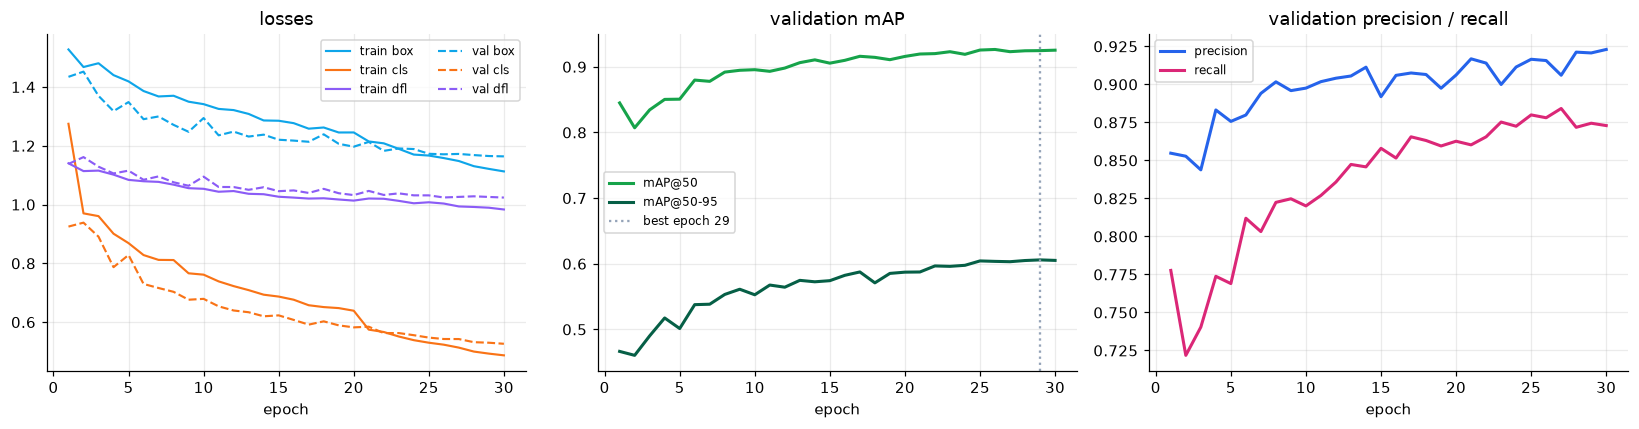

best epoch 29: mAP@50 0.925   mAP@50-95 0.606


In [12]:
history = pd.read_csv(f"{RUN}/results.csv")
history.columns = [c.strip() for c in history.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for split, style in (("train", "-"), ("val", "--")):
    for loss, colour in (("box_loss", "#0ea5e9"), ("cls_loss", "#f97316"), ("dfl_loss", "#8b5cf6")):
        col = f"{split}/{loss}"
        if col in history:
            axes[0].plot(history.epoch, history[col], style, color=colour, lw=1.4,
                         label=f"{split} {loss.split('_')[0]}")
axes[0].set_title("losses"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=8, ncol=2)

axes[1].plot(history.epoch, history["metrics/mAP50(B)"], color="#16a34a", lw=2, label="mAP@50")
axes[1].plot(history.epoch, history["metrics/mAP50-95(B)"], color="#065f46", lw=2, label="mAP@50-95")
best = history["metrics/mAP50-95(B)"].idxmax()
axes[1].axvline(history.epoch[best], color="#94a3b8", ls=":",
                label=f"best epoch {int(history.epoch[best])}")
axes[1].set_title("validation mAP"); axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=8)

axes[2].plot(history.epoch, history["metrics/precision(B)"], color="#2563eb", lw=2, label="precision")
axes[2].plot(history.epoch, history["metrics/recall(B)"], color="#db2777", lw=2, label="recall")
axes[2].set_title("validation precision / recall"); axes[2].set_xlabel("epoch"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"best epoch {int(history.epoch[best])}: "
      f"mAP@50 {history['metrics/mAP50(B)'][best]:.3f}   "
      f"mAP@50-95 {history['metrics/mAP50-95(B)'][best]:.3f}")

## 4. Results

`evaluate.py` runs the trained weights over the val split and the **held-out test split**,
which is touched exactly once, after model selection. Both are reported below — if the two
agree, the val numbers were not overfit by early stopping.

In [13]:
metrics = json.load(open("results/metrics.json"))

frames = []
for split in ("val", "test"):
    df = pd.DataFrame(metrics[split]["per_class"]).T
    df.loc["all"] = metrics[split]["overall"]
    df.columns = ["precision", "recall", "mAP50", "mAP50_95"]
    frames.append(df.assign(split=split).set_index("split", append=True).swaplevel())
report = pd.concat(frames)
report.style.format("{:.3f}").background_gradient(cmap="Greens", vmin=0.3, vmax=1.0)

In [14]:
o = metrics["test"]["overall"]; head = metrics["test"]["per_class"]["head"]
print(f"TEST  mAP@50 {o['mAP50']:.3f}   mAP@50-95 {o['mAP50_95']:.3f}   "
      f"precision {o['precision']:.3f}   recall {o['recall']:.3f}")
print(f"      head (the safety class): recall {head['recall']:.3f}, precision {head['precision']:.3f}")
speed = metrics["test"]["speed_ms"]
print(f"      {sum(speed.values()):.1f} ms per image end to end "
      f"({1000 / sum(speed.values()):.0f} FPS on Apple M3 / MPS)")

TEST  mAP@50 0.954   mAP@50-95 0.636   precision 0.942   recall 0.894
      head (the safety class): recall 0.894, precision 0.942
      9.0 ms per image end to end (111 FPS on Apple M3 / MPS)


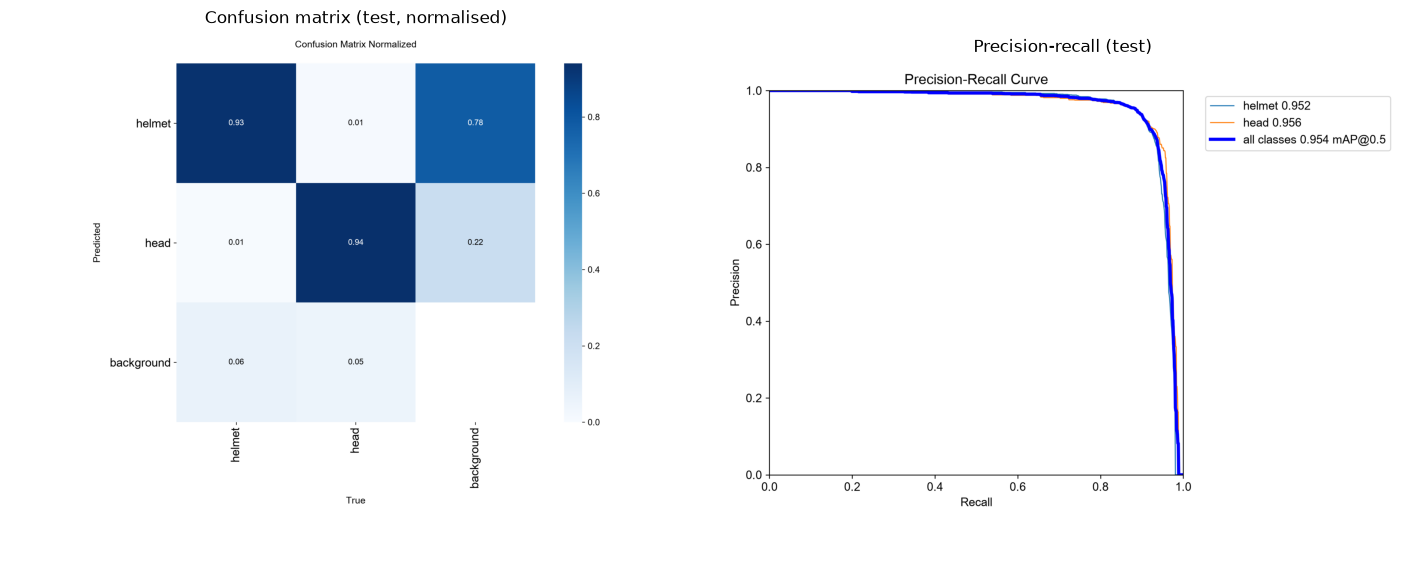

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, name, title in zip(axes, ["confusion_matrix.png", "pr_curve.png"],
                           ["Confusion matrix (test, normalised)", "Precision-recall (test)"]):
    ax.imshow(Image.open(f"results/{name}")); ax.set_title(title, fontsize=11); ax.axis("off")
plt.tight_layout(); plt.show()

The confusion matrix is where the interesting failure lives. Helmet/head confusion is rare —
the model has learned the actual visual distinction — and almost all of the residual error is
against **background**: small distant heads that are missed, not heads called helmets. For a
safety alarm that is the better failure mode to have, and it is the one that shrinks as the
camera gets closer.

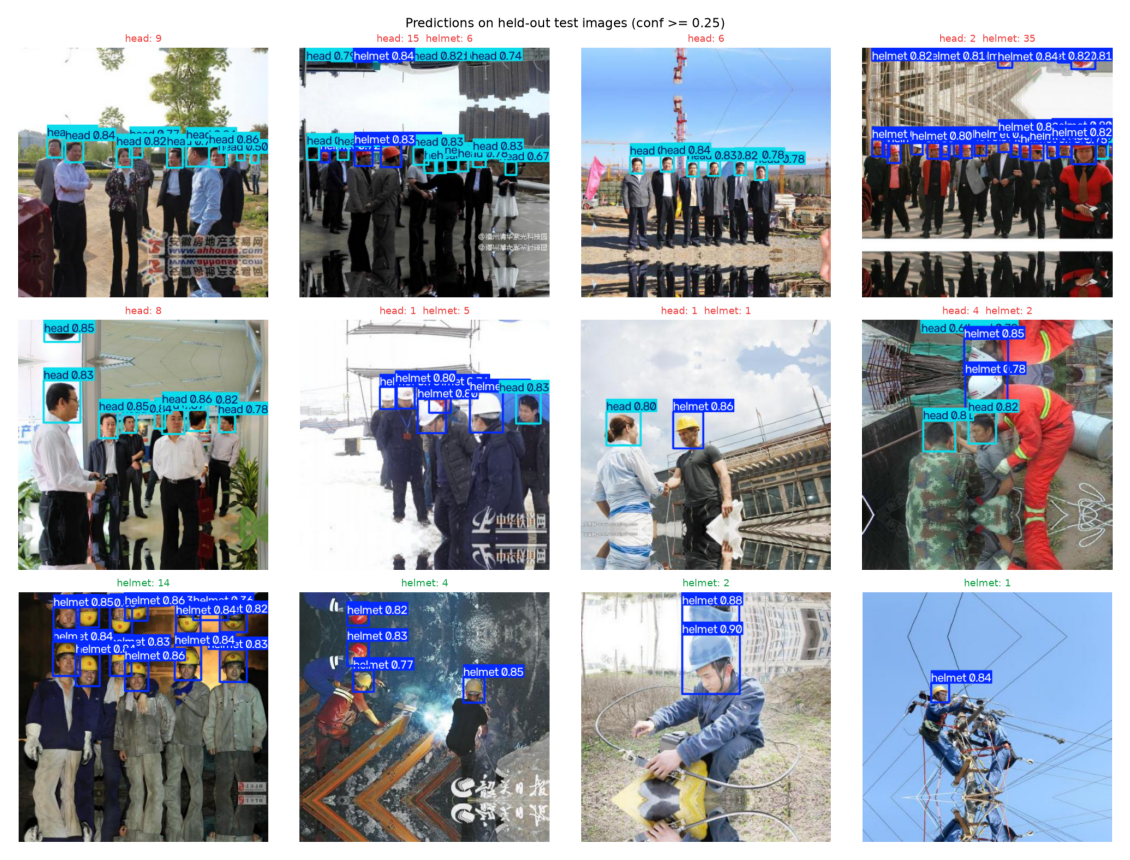

In [16]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.imshow(Image.open("results/predictions_grid.png")); ax.axis("off"); plt.show()

## 5. Picking the alarm threshold

`mAP` summarises every threshold at once, which is the right thing for comparing models and
the wrong thing for running one. A deployed safety camera needs a single confidence cut-off,
and the cost of the two errors is not symmetric:

* a **missed bare head** is a worker exposed and an alarm that never fires;
* a **false alarm** is a supervisor glancing at a frame.

So the operating point should be chosen on `head` **recall**, accepting the precision it
costs. The sweep below runs the detector over the test split at a range of thresholds and
matches predictions to ground truth at IoU 0.5.

In [17]:
from ultralytics import YOLO

model = YOLO(f"{RUN}/weights/best.pt")
test_images = sorted(glob.glob(os.path.join(cfg["path"], "images", "test", "*.png")))
HEAD = CLASSES.index("head")

def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-9)

# One low-threshold pass; the sweep then filters those detections by score.
detections, truths = [], []
for path in test_images:
    result = model.predict(path, conf=0.01, imgsz=416, verbose=False)[0]
    keep = result.boxes.cls.cpu().numpy() == HEAD
    detections.append((result.boxes.xyxy.cpu().numpy()[keep],
                       result.boxes.conf.cpu().numpy()[keep]))
    stem = os.path.splitext(os.path.basename(path))[0]
    gt = [l.split() for l in open(os.path.join(cfg["path"], "labels", "test", f"{stem}.txt")).read().split("\n") if l]
    W, H = Image.open(path).size
    truths.append(np.array([[(float(cx) - float(w) / 2) * W, (float(cy) - float(h) / 2) * H,
                             (float(cx) + float(w) / 2) * W, (float(cy) + float(h) / 2) * H]
                            for c, cx, cy, w, h in gt if int(c) == HEAD]).reshape(-1, 4))
print(f"{sum(len(t) for t in truths):,} ground-truth heads in the test split")

604 ground-truth heads in the test split


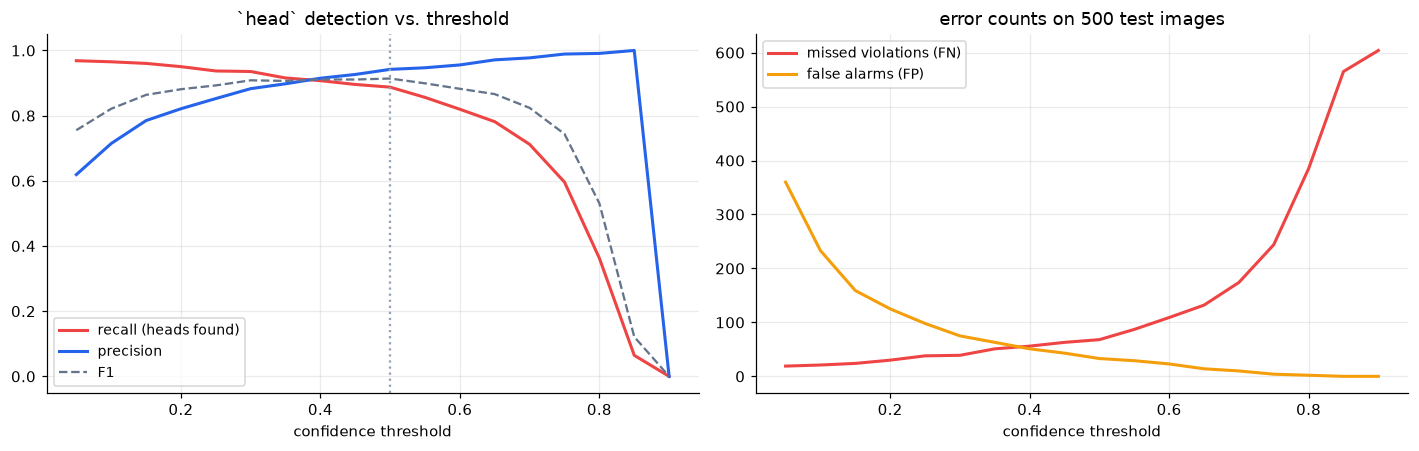

conf,precision,recall,f1,missed heads,false alarms
0.05,0.619,0.969,0.755,19,360
0.10,0.714,0.965,0.821,21,233
0.15,0.785,0.960,0.864,24,159
0.20,0.821,0.950,0.881,30,125
0.25,0.852,0.937,0.893,38,98
0.30,0.883,0.935,0.908,39,75
0.35,0.898,0.916,0.907,51,63
0.40,0.915,0.907,0.911,56,51
0.45,0.926,0.896,0.911,63,43
0.50,0.942,0.887,0.914,68,33


In [18]:
def score_at(threshold, iou_thr=0.5):
    tp = fp = fn = 0
    for (boxes_p, scores), gt in zip(detections, truths):
        pred = boxes_p[scores >= threshold]
        order = np.argsort(-scores[scores >= threshold])
        pred = pred[order]
        matched = set()
        ious = iou_matrix(pred, gt)
        for i in range(len(pred)):
            best_j, best_iou = -1, iou_thr
            for j in range(len(gt)):
                if j not in matched and ious[i, j] >= best_iou:
                    best_j, best_iou = j, ious[i, j]
            if best_j >= 0:
                matched.add(best_j); tp += 1
            else:
                fp += 1
        fn += len(gt) - len(matched)
    precision = tp / max(tp + fp, 1); recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    return {"conf": threshold, "precision": precision, "recall": recall, "f1": f1,
            "missed heads": fn, "false alarms": fp}

sweep = pd.DataFrame([score_at(t) for t in np.round(np.arange(0.05, 0.91, 0.05), 2)])
sweep.to_csv("results/threshold_sweep.csv", index=False)  # the README quotes these numbers

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(sweep.conf, sweep.recall, color="#ef4444", lw=2, label="recall (heads found)")
axes[0].plot(sweep.conf, sweep.precision, color="#2563eb", lw=2, label="precision")
axes[0].plot(sweep.conf, sweep.f1, color="#64748b", lw=1.5, ls="--", label="F1")
best_f1 = sweep.loc[sweep.f1.idxmax()]
axes[0].axvline(best_f1.conf, color="#94a3b8", ls=":")
axes[0].set_xlabel("confidence threshold"); axes[0].set_title("`head` detection vs. threshold")
axes[0].legend(fontsize=9)

axes[1].plot(sweep.conf, sweep["missed heads"], color="#ef4444", lw=2, label="missed violations (FN)")
axes[1].plot(sweep.conf, sweep["false alarms"], color="#f59e0b", lw=2, label="false alarms (FP)")
axes[1].set_xlabel("confidence threshold"); axes[1].set_title("error counts on 500 test images")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

sweep.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}", "conf": "{:.2f}"}).hide(axis="index")

In [19]:
balanced = sweep.loc[sweep.f1.idxmax()]
safety = sweep[sweep.precision >= 0.80].iloc[0] if (sweep.precision >= 0.80).any() else sweep.iloc[0]
print(f"F1-optimal threshold      : conf {balanced.conf:.2f}  -> recall {balanced.recall:.1%}, "
      f"precision {balanced.precision:.1%}, {int(balanced['missed heads'])} missed heads")
print(f"Recall-first alternative  : conf {safety.conf:.2f}  -> recall {safety.recall:.1%}, "
      f"precision {safety.precision:.1%}, {int(safety['missed heads'])} missed heads, "
      f"{int(safety['false alarms'])} false alarms")

F1-optimal threshold      : conf 0.50  -> recall 88.7%, precision 94.2%, 68 missed heads
Recall-first alternative  : conf 0.20  -> recall 95.0%, precision 82.1%, 30 missed heads, 125 false alarms


## 6. Deployment

Two entry points ship with the repo, both loading the same `best.pt`:

```bash
python app.py                       # Gradio: upload or webcam, returns a compliance verdict
python predict_video.py --source 0  # live webcam with a running violation banner
```

The app answers in the language of the use case — *"⚠️ 2 of 7 heads unprotected"* — rather
than just drawing boxes, because that is the output an inspector acts on.

In [20]:
import time
warm = model.predict(test_images[0], imgsz=416, verbose=False)
started = time.time()
for path in test_images[:100]:
    model.predict(path, imgsz=416, conf=0.25, verbose=False)
elapsed = (time.time() - started) / 100 * 1000
print(f"{elapsed:.1f} ms per 416x416 image on Apple M3 / MPS  ->  {1000 / elapsed:.0f} FPS")
print(f"model parameters: {sum(p.numel() for p in model.model.parameters()):,}")

30.8 ms per 416x416 image on Apple M3 / MPS  ->  32 FPS
model parameters: 11,126,358


## 7. What this model is and is not

**It works.** On 500 unseen images the detector finds unprotected heads reliably enough to be
useful as a first-pass safety filter, at real-time speed on a laptop with no GPU.

**Where it will struggle**, and what would fix it:

* **Very small / far heads.** Most residual misses are heads a few pixels across. Training at
  640 px (or tiling large frames) is the obvious next lever — it was measured here and skipped
  only because this laptop swaps at that memory footprint, not because it would not help.
* **Domain shift.** The dataset is dominated by daylight construction scenes. Night, rain,
  helmet colours or camera angles outside that distribution are untested — fine-tuning on a
  few hundred site-specific frames is the standard remedy.
* **Occlusion and crowds.** Heads behind scaffolding or in dense groups get merged or missed;
  tracking across frames (rather than judging single frames) recovers a lot of them.
* **`person` was dropped.** A worker whose head is not visible is invisible to this model. A
  deployment that must count *everyone* would train the 3-class variant and reason about
  person-without-head as "unknown" rather than "compliant".
* **One frame is not one decision.** In production the alarm should require a violation to
  persist over several frames — the threshold sweep above sets the per-frame operating point
  that such a rule would sit on top of.